# ITHILDIN Segmentation Model Training (Google Colab Version)

This notebook trains a wing segmentation model using UNet++ with EfficientNet-b0 encoder.

## Requirements
- **GPU Runtime**: Runtime > Change runtime type > Hardware accelerator > GPU
- **Training Data**: Upload your training data (.npy files) to Google Drive
- **Disk Space**: Ensure sufficient space for model checkpoints

## Instructions
1. **Configure**: Edit the configuration cell below with your paths and parameters
2. **Mount Drive**: Run the Google Drive mounting cell
3. **Run All**: Execute all cells in order (Runtime > Run all)
4. **Monitor**: Watch training progress and metrics
5. **Results**: Trained models will be saved to your specified Google Drive path

## Set up Training Pipeline

In [ ]:
!pip install segmentation-models-pytorch

In [ ]:
import os
import torch
import wandb
import math
import json
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt
import skimage as ski
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF
import segmentation_models_pytorch as smp

from torchvision.transforms import v2
from torch.utils.data import Dataset, DataLoader, SubsetRandomSampler
from skimage.morphology import skeletonize, dilation
from sklearn.model_selection import train_test_split, KFold

In [ ]:
# Get cpu, gpu or mps device for training.
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using cuda device


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Configuration Parameters

**Edit these parameters for your experiment.**

In [ ]:
# ============================================================================
# CONFIGURATION - EDIT THESE PARAMETERS FOR YOUR EXPERIMENT
# ============================================================================

# Path to your training data on Google Drive
# This folder should contain image_forsegment.npy and segment_forsegment.npy files
DIR_path = "/content/drive/MyDrive/ITHILDIN_example/"

# Training Hyperparameters
learning_rate = 1e-4  # Initial learning rate
epochs = 16  # Total number of training epochs
batch_size = 8  # Batch size (reduce if you get memory errors)
image_size = 640  # Input image size (square images)

# Loss Function Parameters
alpha = 0.25  # Weight balance between focal and skeleton loss (0 to 1)

# Learning Rate Scheduler Parameters
warmup_epochs = 8  # Number of warmup epochs
warmup_factor = .05  # Starting learning rate multiplier

# Cross-Validation Settings
k_folds = 5  # Number of folds for cross-validation
fold = 0  # Which fold to train on (0 to k_folds-1)

# Pretrained Model Settings (Optional)
pretrained_bool = True  # Set to True to load pretrained weights
pretrained_model_path = DIR_path + "mosquito_segmentation_weights_fold-0.pth"  # Path to pretrained model if pretrained_bool is True

# Hardware Settings
num_workers = 12  # Number of data loading workers

## Load the Dataset

In [ ]:
class CustomDataset(Dataset):
    def __init__(self, file_path_input, file_path_output, input_transforms, output_transforms, augment_transforms, augment_bool=False):
        self.input = np.load(file_path_input).astype(np.float32)
        self.output = np.load(file_path_output).astype(np.float32)
        self.input_transforms = input_transforms
        self.output_transforms = output_transforms
        self.augment_transforms = augment_transforms
        self.augment_bool = augment_bool

    def __len__(self):
        return len(self.input)

    def geo_transform(self, input, output):
        # Random rotation
        angle = transforms.RandomRotation.get_params((-5, 5))
        input = TF.rotate(input, angle)
        output = TF.rotate(output, angle)

        # Random horizontal flipping
        if torch.rand(1) > 0.5:
            input = TF.hflip(input)
            output = TF.hflip(output)

        # Random shear
        params = transforms.RandomAffine.get_params(degrees=(0, 0), translate=(0, 0), scale_ranges=(1, 1), shears=(-15, 15), img_size=(int(image_size * 0.5), image_size))
        shear_x, shear_y = params[-1]
        input = TF.affine(input, angle=params[0], translate=params[1], scale=params[2], shear=(shear_x, shear_y))
        output = TF.affine(output, angle=params[0], translate=params[1], scale=params[2], shear=(shear_x, shear_y))

        return input, output

    def CLAHE_transform(self, image):
                # redice dimension
                image = torch.mean(image, dim=0).numpy()
                # apply CLAHE
                equalized_img = ski.exposure.equalize_adapthist(image, clip_limit=.1, nbins=128) 
                # Use mediean filter to reduce noise
                equalized_img = ski.filters.median(equalized_img, ski.morphology.disk(2))

                return torch.tensor(equalized_img, dtype=torch.float32)

    def __getitem__(self, idx):
        input = self.input[idx]
        output = self.output[idx]

        input = self.input_transforms(input)
        output = self.output_transforms(output)

        if self.augment_bool:
            input, output = self.geo_transform(input, output)
            input = self.augment_transforms(input)

        input = torch.clamp(input, 0, 1)
        input = self.CLAHE_transform(input).unsqueeze(0)

        output = torch.clamp(output, 0, 1)

        return (input, output)

input_trans = transforms.Compose([transforms.ToTensor(),
                                   transforms.Resize((image_size*.5, image_size))])

output_trans = transforms.Compose([transforms.ToTensor(),
                                    transforms.Resize((image_size*.5, image_size))])

color_trans = transforms.Compose([v2.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.1),
                                  v2.GaussianBlur(kernel_size=5, sigma=(0.5, 1.5)),
                                  v2.RandomPosterize(bits=8, p=0.1),
                                  v2.RandomAutocontrast(p=0.1),
                                  v2.RandomAdjustSharpness(sharpness_factor=2.0, p=0.2),
                                  v2.RandomGrayscale(p=.2),])

# Create an instance of the CustomDataset
dataset = CustomDataset(file_path_input = path + "image_forsegment.npy",
                        file_path_output = path + "segment_forsegment.npy",
                        input_transforms=input_trans,
                        output_transforms=output_trans,
                        augment_transforms=color_trans,
                        augment_bool=True)

# Create KFold splitter
kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)

# Generate all fold splits
splits = list(kf.split(np.arange(len(dataset))))

# Select the fold you want
train_indices, test_indices = splits[fold]

# Create samplers
train_sampler = SubsetRandomSampler(train_indices)
test_sampler = SubsetRandomSampler(test_indices)

# Create dataloaders
train_dataloader = DataLoader(dataset, batch_size=batch_size, sampler=train_sampler, num_workers=12)
test_dataloader = DataLoader(dataset, batch_size=batch_size, sampler=test_sampler, num_workers=12)

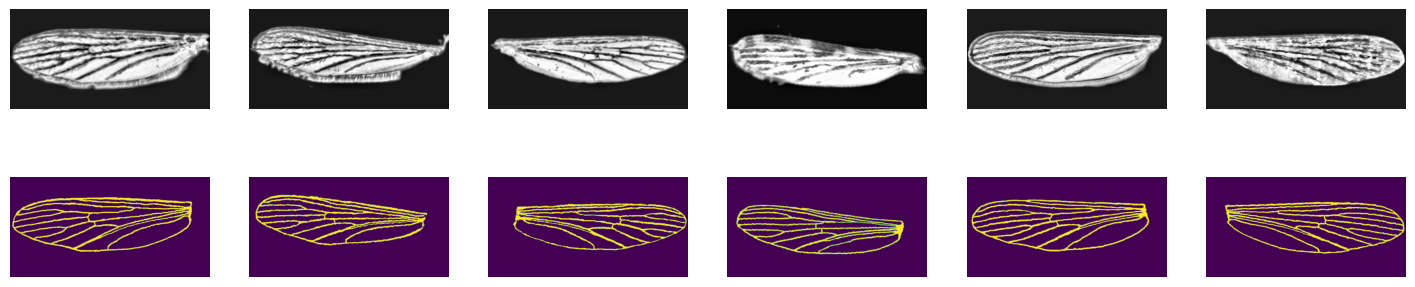

In [ ]:
#Preview
fig, ax = plt.subplots(2,6, figsize=(18, 4))
for i in range(6):
    image, label = next(iter(train_dataloader))

    image = image[0][0]
    label = label[0][0]

    ax[0][i].imshow(image, cmap="Greys_r")
    ax[1][i].imshow(label)

for a in ax.ravel(): a.axis('off')

In [ ]:
class AddCoords(nn.Module):
    """
    A layer that appends normalized x and y coordinate channels (and optionally a radial channel)
    to the input tensor for CoordConv operations.
    """
    def __init__(self, with_r=False):
        """
        Args:
            with_r (bool): Whether to include a radial distance channel sqrt(x^2 + y^2).
        """
        super(AddCoords, self).__init__()
        self.with_r = with_r

    def forward(self, input_tensor):
        """
        Args:
            input_tensor (Tensor): Input of shape (B, C, H, W)

        Returns:
            Tensor: Output tensor with added coordinate channels.
        """
        batch_size, _, height, width = input_tensor.size()

        # Generate normalized x and y coordinates in range [-1, 1]
        xx_channel = torch.arange(width).repeat(1, height, 1)
        yy_channel = torch.arange(height).repeat(1, width, 1).transpose(1, 2)

        xx_channel = xx_channel.float() / (width - 1)
        yy_channel = yy_channel.float() / (height - 1)

        xx_channel = xx_channel * 2 - 1  # Normalize to [-1, 1]
        yy_channel = yy_channel * 2 - 1

        # Expand to batch size and add channel dimension
        xx_channel = xx_channel.repeat(batch_size, 1, 1, 1).to(input_tensor.device)
        yy_channel = yy_channel.repeat(batch_size, 1, 1, 1).to(input_tensor.device)

        # Concatenate coordinates with input
        coords = torch.cat([input_tensor, xx_channel, yy_channel], dim=1)

        # Optionally add radial distance channel
        if self.with_r:
            rr = torch.sqrt(xx_channel ** 2 + yy_channel ** 2)
            coords = torch.cat([coords, rr], dim=1)

        return coords


class CoordConvUnet(nn.Module):
    """
    A wrapper around a segmentation model that adds CoordConv channels to the input.
    """
    def __init__(self, base_model):
        """
        Args:
            base_model (nn.Module): A segmentation model (e.g., Unet++) with in_channels=3.
        """
        super().__init__()
        self.addcoords = AddCoords(with_r=False)
        self.base_model = base_model

    def forward(self, x):
        """
        Args:
            x (Tensor): Input tensor of shape (B, 1, H, W) — original image.

        Returns:
            Tensor: Segmentation output from base model.
        """
        x = self.addcoords(x)  # Add x and y coord channels to input
        return self.base_model(x)


def get_model(model_path=pretrained_model_path, pretrained=pretrained_bool):
    """
    Instantiates the CoordConv-enhanced Unet++ segmentation model,
    loads pretrained weights, and returns it.

    Returns:
        nn.Module: Fully constructed segmentation model.
    """
    # Create the base Unet++ model with EfficientNet-b0 encoder
    base_model = smp.UnetPlusPlus(
        encoder_name="efficientnet-b0",
        encoder_weights="imagenet",
        in_channels=3,  # 1 channel image + 2 coord channels
        classes=1       # Binary segmentation output
    )

    # Wrap with CoordConv layer
    model = CoordConvUnet(base_model).to(device)

    if pretrained:
        # Load pretrained weights
        model.load_state_dict(torch.load(model_path, map_location=device))

    return model

print("\nCreating segmentation model...")
model = get_model(model_path=pretrained_model_path, pretrained=pretrained_bool).to(device)

if pretrained_bool and pretrained_model_path and os.path.exists(pretrained_model_path):
    print(f"Loading pretrained weights from: {pretrained_model_path}")
    model.load_state_dict(torch.load(pretrained_model_path, map_location=device))

print(f"Model created with {sum(p.numel() for p in model.parameters())} parameters")

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

## Loss Functions

In [ ]:
def skeletonize_mask(mask, threshold=0.5):
    #Create a boolean mask from the prediction
    bool_mask = mask[0].cpu().detach().numpy() > threshold

    # Skeletonize the mask
    skeleton = skeletonize(bool_mask)

    # Make Tube around skeleton but ensure that tube is not larger than the original mask
    skeleton = dilation(dilation(skeleton)) * bool_mask

    # Ensure that the skeleton is of the same type as the original mask
    skeleton = skeleton.astype(np.int16) > 0

    return torch.tensor(skeleton, dtype=torch.float32)

def skeleton_recall_loss(pred, target, smooth=1e-6, batch_recall=False):
    # Skeletonize the target and predicted masks
    pred_skeleton = skeletonize_mask(pred)
    target_skeleton = skeletonize_mask(target)

    # Calculate soft true positives as the sum of relevant predictions in the true positive region
    soft_true_positives = torch.sum((pred_skeleton * target_skeleton))

    # Calculate the total actual positives in true_mask
    actual_positives = torch.sum(target_skeleton)

    # Compute soft recall with smoothing to avoid division by zero
    soft_recall_value = (soft_true_positives + smooth) / (actual_positives + smooth)

    # If batch recall is enabled, take the mean across the batch dimension
    if batch_recall:
        soft_recall_value = soft_recall_value.mean()

    return 1 - soft_recall_value

def soft_dice_loss(pred, target, smooth=1e-6):
    # Calculate the intersection between the prediction and target
    intersection = (pred * target).sum()

    # Calculate the Dice coefficient
    dice = (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)

    return 1 - dice

def focal_loss(pred, target, gamma=2, alpha=0.25, smooth=1e-6):
    # Calculate the intersection between the prediction and target
    intersection = (pred * target).sum()

    # Calculate the Dice coefficient
    dice = (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)

    # Calculate the focal loss
    focal_loss = -alpha * (1 - dice)**gamma * torch.log(dice)

    return focal_loss

def combined_loss(pred, target, alpha):
    # Apply non-linear activation to the prediction
    pred = torch.sigmoid(pred)

    # Calculate Dice Loss
    general_loss = focal_loss(pred, target)

    # Calculate Skeleton Recall Loss
    skeleton_loss = skeleton_recall_loss(pred, target)

    # Combine the losses
    return alpha * general_loss + (1 - alpha) * skeleton_loss

## Define Loss and Learning Scheduele

In [ ]:
# Define optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

# Define scheduler
def lr_lambda(current_epoch):
    if current_epoch < warmup_epochs:
        # Linear warm-up
        return warmup_factor + (1 - warmup_factor) * (current_epoch / warmup_epochs)
    else:
        # Cosine decay
        progress = (current_epoch - warmup_epochs) / (epochs - warmup_epochs)
        return 0.5 * (1 + math.cos(math.pi * progress))

# Create the LambdaLR scheduler
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)

def train_loop(dataloader, model, epoch):
    model.train()
    total_loss = 0
    total_IoU = 0
    total_soft_dice_loss = 0
    total_soft_recall_loss = 0
    total_batches = len(dataloader)

    for batch, (X, y) in enumerate(dataloader):
        # Compute prediction and loss
        X = X.to(device)
        y = y.to(device)

        pred = model(X)
        loss = combined_loss(pred, y, alpha=alpha)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        # Calculate metrics
        pred = torch.sigmoid(pred)

        total_loss += loss.item()
        tp, fp, fn, tn = smp.metrics.get_stats(pred > .5, y > .5, mode='binary')
        total_IoU += smp.metrics.iou_score(tp, fp, fn, tn).mean()
        total_soft_dice_loss += soft_dice_loss(pred, y)
        total_soft_recall_loss += skeleton_recall_loss(pred, y)


    # Average metrics for the epoch
    avg_loss = total_loss / total_batches
    avg_dice = total_soft_dice_loss / total_batches
    avg_recall = total_soft_recall_loss / total_batches
    avg_iou = total_IoU / total_batches

    print(f"Epoch {epoch}: Loss: {avg_loss:.3f}, Dice: {avg_dice:.3f}, SoftSkel-Recall: {avg_recall:.3f}, IoU: {avg_iou:.3f}")

    scheduler.step()

def test_loop(dataloader, model, epoch):
    model.eval()
    total_loss = 0
    total_IoU = 0
    total_soft_dice_loss = 0
    total_soft_recall_loss = 0
    total_batches = len(dataloader)

    with torch.no_grad():
        for batch, (X, y) in enumerate(dataloader):
            # Compute prediction and loss
            X = X.to(device)
            y = y.to(device)

            pred = model(X)
            loss = combined_loss(pred, y, alpha=alpha)

            # Calculate metrics
            pred = torch.sigmoid(pred)

            total_loss += loss.item()
            tp, fp, fn, tn = smp.metrics.get_stats(pred > .5, y > .5, mode='binary')
            total_IoU += smp.metrics.iou_score(tp, fp, fn, tn).mean()
            total_soft_dice_loss += soft_dice_loss(pred, y)
            total_soft_recall_loss += skeleton_recall_loss(pred, y)

    # Average metrics for the epoch
    avg_loss = total_loss / total_batches
    avg_dice = total_soft_dice_loss / total_batches
    avg_recall = total_soft_recall_loss / total_batches
    avg_iou = total_IoU / total_batches

    print(f"Validation: Loss: {avg_loss:.3f}, Dice: {avg_dice:.3f}, SoftSkel-Recall: {avg_recall:.3f}, IoU: {avg_iou:.3f}")
    print("-----------------------------------------------------")

## Train Model

In [ ]:
for t in range(epochs):
    train_loop(train_dataloader, model, t)
    test_loop(test_dataloader, model, t)

Epoch 0: Loss: 0.291, Dice: 0.728, SoftSkel-Recall: 0.328, IoU: 0.342
Validation: Loss: 0.188, Dice: 0.795, SoftSkel-Recall: 0.168, IoU: 0.248
-----------------------------------------------------
Epoch 1: Loss: 0.209, Dice: 0.584, SoftSkel-Recall: 0.252, IoU: 0.473
Validation: Loss: 0.266, Dice: 0.700, SoftSkel-Recall: 0.305, IoU: 0.419
-----------------------------------------------------
Epoch 2: Loss: 0.184, Dice: 0.449, SoftSkel-Recall: 0.235, IoU: 0.568
Validation: Loss: 0.196, Dice: 0.559, SoftSkel-Recall: 0.239, IoU: 0.570
-----------------------------------------------------
Epoch 3: Loss: 0.162, Dice: 0.360, SoftSkel-Recall: 0.212, IoU: 0.615
Validation: Loss: 0.191, Dice: 0.434, SoftSkel-Recall: 0.245, IoU: 0.609
-----------------------------------------------------
Epoch 4: Loss: 0.154, Dice: 0.306, SoftSkel-Recall: 0.202, IoU: 0.642
Validation: Loss: 0.176, Dice: 0.351, SoftSkel-Recall: 0.230, IoU: 0.635
-----------------------------------------------------
Epoch 5: Loss: 

In [ ]:
# save pytorch model
torch.save(model, DIR_path + "segmentation_fold-{}.pth".format(fold))
torch.save(model.state_dict(), DIR_path + "segmentation_weights_fold-{}.pth".format(fold))

## Evaluate model

In [ ]:
def evaluate_model(dataloader, model):
    model.eval()
    total_loss = 0
    total_IoU = 0
    total_soft_dice_loss = 0
    total_soft_recall_loss = 0
    total_batches = len(dataloader)

    with torch.no_grad():
        for batch, (X, y) in enumerate(dataloader):
            X = X.to(device)
            y = y.to(device)

            pred = model(X)
            loss = combined_loss(pred, y, alpha=alpha)

            pred = torch.sigmoid(pred)

            total_loss += loss.item()
            tp, fp, fn, tn = smp.metrics.get_stats(pred > .5, y > .5, mode='binary')
            total_IoU += smp.metrics.iou_score(tp, fp, fn, tn).mean()
            total_soft_dice_loss += soft_dice_loss(pred, y)
            total_soft_recall_loss += skeleton_recall_loss(pred, y)

    avg_loss = total_loss / total_batches
    avg_dice = total_soft_dice_loss / total_batches
    avg_recall = total_soft_recall_loss / total_batches
    avg_iou = total_IoU / total_batches

    metrics = {
        "loss": avg_loss,
        "dice_loss": avg_dice.item(),
        "skeleton_recall_loss": avg_recall.item(),
        "iou": avg_iou.item()
    }

    return metrics

metrics = evaluate_model(test_dataloader, model)

# Save metrics to JSON
with open(DIR_path + "evaluation_metrics_fold-{}.json".format(fold), 'w') as f:
    json.dump(metrics, f)

print("Evaluation Metrics:")
print(metrics)

Evaluation Metrics:
{'loss': 0.16498448550701142, 'dice_loss': 0.19114641845226288, 'skeleton_recall_loss': 0.15626385807991028, 'iou': 0.7016498446464539}


/tmp/ipython-input-2601890082.py:18: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  ax[i][3].imshow(ground_truth[i][0] - torch.sigmoid(test_output[i][0]).detach().cpu().numpy(), cmap='seismic', vmin=-1, vmax=1)


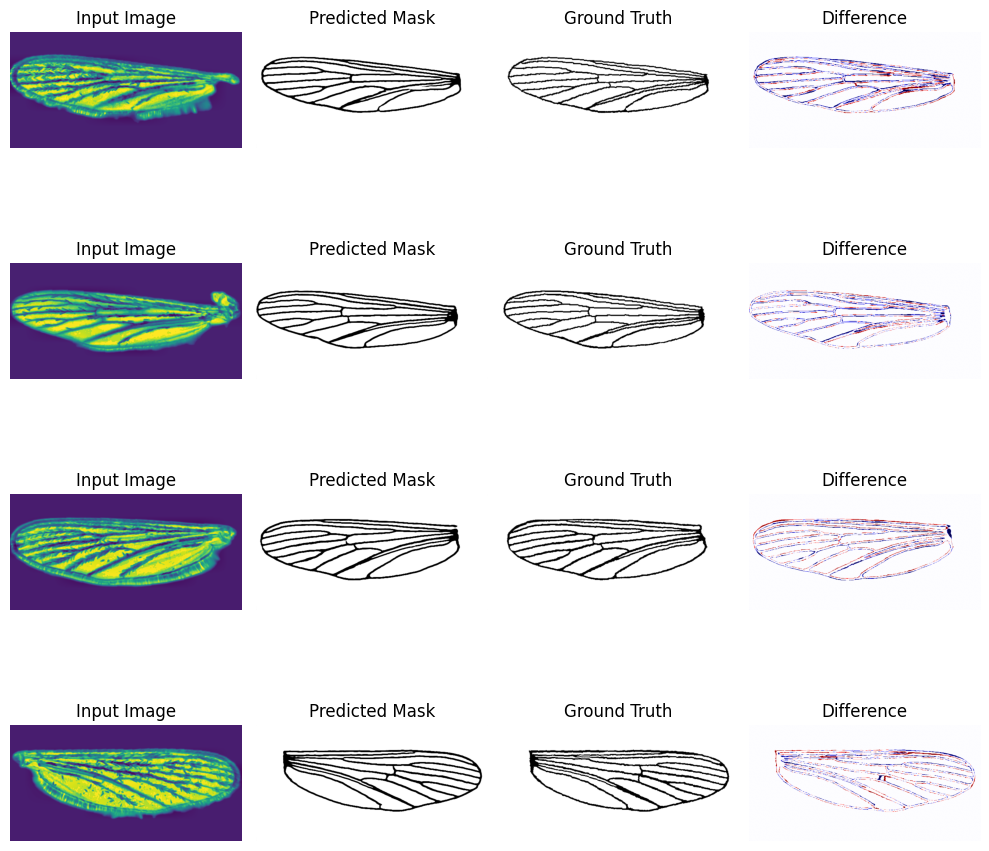

In [ ]:
model.eval()

test_input, ground_truth = next(iter(test_dataloader))
test_output = model(test_input.to(device))

fig, ax = plt.subplots(4, 4, figsize=(10, 10), sharex=True, sharey=True)
for i in range(4):

    ax[i][0].imshow(test_input[i][0])
    ax[i][0].set_title("Input Image")

    ax[i][1].imshow(torch.sigmoid(test_output[i][0]).detach().cpu().numpy(), cmap="gist_yarg")
    ax[i][1].set_title("Predicted Mask")

    ax[i][2].imshow(ground_truth[i][0], cmap="gist_yarg")
    ax[i][2].set_title("Ground Truth")

    ax[i][3].imshow(ground_truth[i][0] - torch.sigmoid(test_output[i][0]).detach().cpu().numpy(), cmap='seismic', vmin=-1, vmax=1)
    ax[i][3].set_title("Difference")

for a in ax.ravel():
    a.axis('off')

plt.tight_layout()